<a href="https://colab.research.google.com/github/knapkova/Deep-Learning-for-Visual-Recognition/blob/tereza/DeepLearning_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fine-Tuning Depth and Cross-Hospital Generalization in Medical Image Classification


In [62]:
from datasets import load_dataset
from google.colab import userdata

ds = load_dataset("wltjr1007/Camelyon17-WILDS", token=userdata.get('HF_TOKEN'))

"""
print("--TEST--")
print(ds['test'].features)
print(ds['test'].num_rows)


print("--TRAIN--")
print(ds['train'].features)
print(ds['train'].num_rows)

print("--VALIDATION--")
print(ds['validation'].features)
print(ds['validation'].num_rows)

"""



'\nprint("--TEST--")\nprint(ds[\'test\'].features)\nprint(ds[\'test\'].num_rows)\n\n\nprint("--TRAIN--")\nprint(ds[\'train\'].features)\nprint(ds[\'train\'].num_rows)\n\nprint("--VALIDATION--")\nprint(ds[\'validation\'].features)\nprint(ds[\'validation\'].num_rows)\n\n'

### Displaying Images from the Dataset

To visualize images from the `ds` dataset, we'll access one of its splits and then iterate through a few samples.

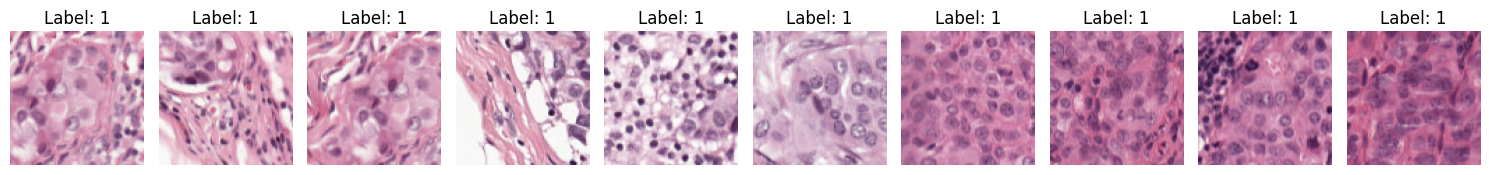

In [63]:
import matplotlib.pyplot as plt

train_dataset = ds['train']
label_feature = ds["train"].features["label"]

fig, axes = plt.subplots(1, 10, figsize=(15, 5))

for i in range(10):
    image = train_dataset[i]['image']
    label = train_dataset[i]['label']

    axes[i].imshow(image)
    axes[i].set_title(f"Label: {label}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [64]:
import torchvision.models as models

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)


import torch.nn as nn
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)



### lab 3
data checks


In [65]:
print(ds["train"].features["label"])

ClassLabel(names=['non-tumor', 'tumor'])


In [66]:
import torch
from torchvision import transforms
from collections import Counter

\

In [67]:
# Standard transforms for ImageNet-trained models
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

In [68]:
from torch.utils.data import Dataset

class Camelyon17Dataset(Dataset):
    def __init__(self, hf_dataset_split, transform=None):
        """
        Args:
            hf_dataset_split: A specific split from the Hugging Face dataset (e.g., ds['train'])
            transform: A PyTorch transform to apply to the images
        """
        self.dataset = hf_dataset_split
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        # Retrieve the PIL image and integer label
        item = self.dataset[idx]
        image = item['image'].convert('RGB')
        label = item['label']

        # Apply transforms if provided
        if self.transform:
            image = self.transform(image)

        return image, label

In [69]:
import os
from PIL import Image
from torch.utils.data import Dataset

class ImageDatasetFromList(Dataset):
    """
    Dataset class loading images from file paths on disk and labels.
    """
    def __init__(self, image_paths, labels, transform=None):
        assert len(image_paths) == len(labels)
        self.image_paths = image_paths
        self.labels      = labels
        self.transform   = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, self.labels[idx]

In [70]:
# To show how this works with your dataset, let's export a small subset of 50 images to your local disk first:
os.makedirs('/content/camelyon17_images', exist_ok=True)

local_image_paths = []
local_labels = []

# Save first 50 images from HF train split to disk
for i in range(50):
    item = ds['train'][i]
    file_path = f'/content/camelyon17_images/img_{i:03d}.png'
    item['image'].save(file_path)

    local_image_paths.append(file_path)
    local_labels.append(item['label'])

# Instantiate using your preferred List-based class!
list_dataset = ImageDatasetFromList(local_image_paths, local_labels, transform=transform)
print(f'Dataset from list: {len(list_dataset)} images successfully mapped from local disk.')
print(f'First item shape: {list_dataset[0][0].shape}, Label: {list_dataset[0][1]} (1=tumor)')

Dataset from list: 50 images successfully mapped from local disk.
First item shape: torch.Size([3, 224, 224]), Label: 1 (1=tumor)


In [71]:
# Example of instantiating and preparing the PyTorch datasets:
train_dataset = Camelyon17Dataset(ds['train'], transform=transform)
val_dataset = Camelyon17Dataset(ds['validation'], transform=transform)
test_dataset = Camelyon17Dataset(ds['test'], transform=transform)

print(f"Wrapped PyTorch train dataset size: {len(train_dataset)}")

Wrapped PyTorch train dataset size: 302436


DataLoader

In [72]:
from torch.utils.data import Dataset, DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

# Check one batch
images, labels = next(iter(train_loader))
print(f'Batch image shape: {images.shape}')   # (32, 3, 224, 224)
print(f'Batch label shape: {labels.shape}')   # (32,)
print(f'Labels in batch:   {labels.tolist()}')

Batch image shape: torch.Size([32, 3, 224, 224])
Batch label shape: torch.Size([32])
Labels in batch:   [0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0]


sanity checks
1) visual samples

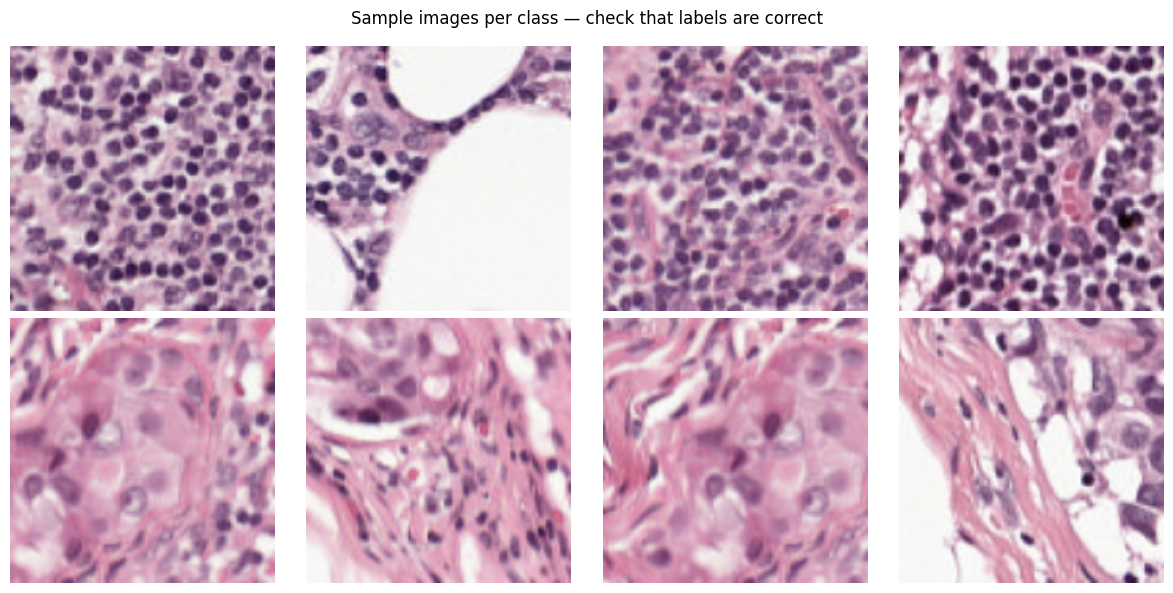

In [73]:
def denormalise(tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    mean = torch.tensor(mean).view(3,1,1)
    std  = torch.tensor(std).view(3,1,1)
    return torch.clamp(tensor * std + mean, 0, 1)

def visualise_samples(dataset, class_names, n_per_class=4):
    """
    Show n_per_class examples from each class.
    Optimized to find indices directly from dataset metadata instead of loading all images sequentially.
    """
    n_classes = len(class_names)
    fig, axes = plt.subplots(
        n_classes, n_per_class,
        figsize=(n_per_class * 3, n_classes * 3)
    )

    # Collect indices per class
    class_indices = {c: [] for c in range(n_classes)}

    # Check if we can get labels from underlying dataset directly to avoid loading images
    if hasattr(dataset, 'dataset') and 'label' in dataset.dataset.features:
        labels = dataset.dataset['label']
        for idx, label in enumerate(labels):
            if len(class_indices[label]) < n_per_class:
                class_indices[label].append(idx)
            if all(len(v) >= n_per_class for v in class_indices.values()):
                break
    else:
        # Fallback for other dataset types
        for idx, (_, label) in enumerate(dataset.samples
                if hasattr(dataset, 'samples') else
                [(None, dataset[i][1]) for i in range(len(dataset))]):
            if len(class_indices[label]) < n_per_class:
                class_indices[label].append(idx)
            if all(len(v) >= n_per_class for v in class_indices.values()):
                break

    for row, (cls, indices) in enumerate(class_indices.items()):
        for col, idx in enumerate(indices[:n_per_class]):
            ax  = axes[row][col] if n_classes > 1 else axes[col]
            img = denormalise(dataset[idx][0]).permute(1,2,0).numpy()
            ax.imshow(img)
            if col == 0:
                ax.set_ylabel(class_names[cls], fontsize=11, fontweight='bold')
            ax.axis('off')

    plt.suptitle('Sample images per class — check that labels are correct', fontsize=12)
    plt.tight_layout()
    plt.show()

visualise_samples(train_dataset, label_feature.names)

class distribution

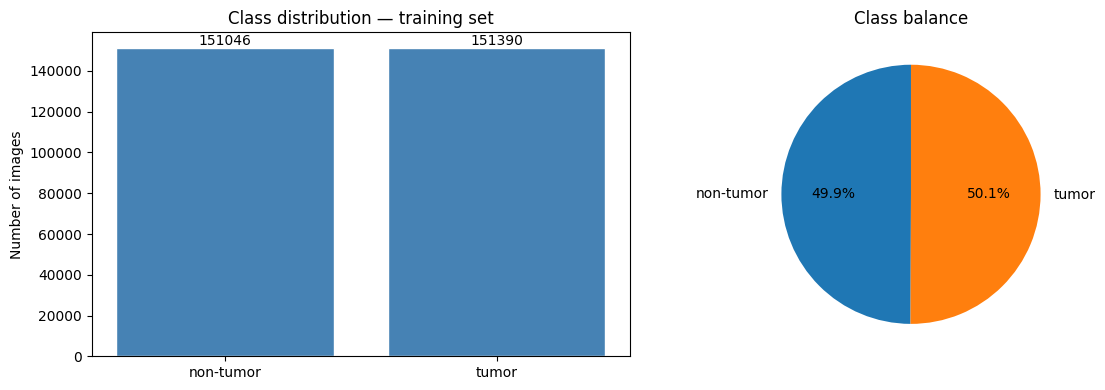

Total: 302436 images
Min class: 151046 (non-tumor)
Max class: 151390 (tumor)
Class imbalance ratio: 1.0x — looks balanced.


In [74]:
def check_class_distribution(dataset, class_names, split_name='dataset'):
    """
    Plot the number of images per class.
    Optimized to fetch labels directly from the underlying dataset without loading images.
    """
    # If it is our Camelyon17Dataset wrapper, get the labels directly from the HF dataset
    if hasattr(dataset, 'dataset') and 'label' in dataset.dataset.features:
        labels = dataset.dataset['label']
    elif hasattr(dataset, 'targets'):
        labels = dataset.targets
    else:
        # Fallback only for small datasets
        labels = [dataset[i][1] for i in range(len(dataset))]

    counts = Counter(labels)
    names  = [class_names[i] for i in sorted(counts.keys())]
    values = [counts[i] for i in sorted(counts.keys())]
    total  = sum(values)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Bar chart
    bars = ax1.bar(names, values, color='steelblue', edgecolor='white')
    ax1.set_title(f'Class distribution — {split_name}')
    ax1.set_ylabel('Number of images')
    for bar, val in zip(bars, values):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(val), ha='center', va='bottom', fontsize=10)

    # Pie chart showing balance
    ax2.pie(values, labels=names, autopct='%1.1f%%', startangle=90)
    ax2.set_title('Class balance')

    plt.tight_layout()
    plt.show()

    print(f'Total: {total} images')
    print(f'Min class: {min(values)} ({names[values.index(min(values))]})')
    print(f'Max class: {max(values)} ({names[values.index(max(values))]})')
    ratio = max(values) / max(min(values), 1)
    if ratio > 3:
        print(f'WARNING: Class imbalance ratio {ratio:.1f}x — consider resampling or weighted loss.')
    else:
        print(f'Class imbalance ratio: {ratio:.1f}x — looks balanced.')

# Run the optimized function
check_class_distribution(train_dataset, label_feature.names, 'training set')

3. image size distribution

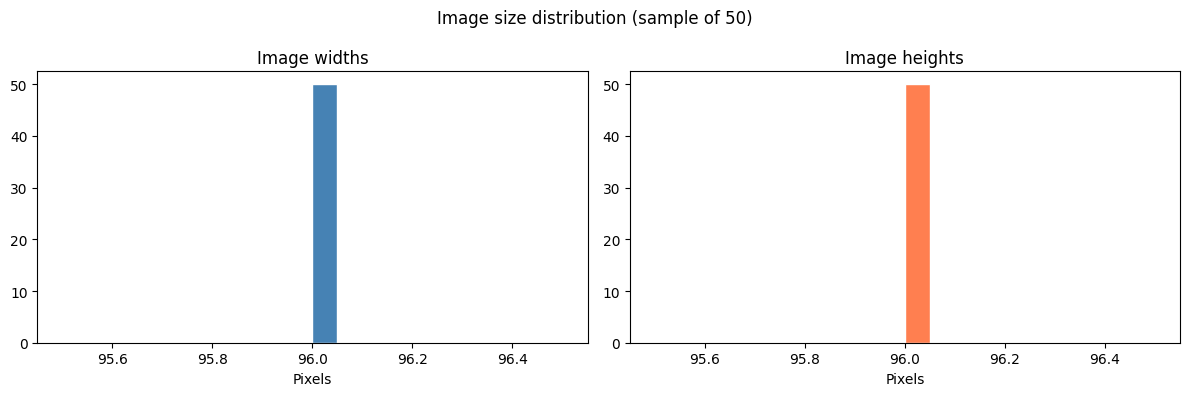

Width:  min=96, max=96, median=96
Height: min=96, max=96, median=96


In [75]:
from pathlib import Path
import numpy as np
import random

def check_image_sizes(image_dir, sample_size=200):
    """
    Check the distribution of original image sizes before resizing.
    Extreme size variation can indicate mixed data sources or quality issues.
    """
    widths, heights = [], []
    images = list(Path(image_dir).rglob('*.jpg')) + \
                  list(Path(image_dir).rglob('*.png')) + \
                  list(Path(image_dir).rglob('*.jpeg'))

    # Sample a subset for speed
    sampled = random.sample(images, min(sample_size, len(images)))

    for path in sampled:
        try:
            with Image.open(path) as img:
                w, h = img.size
                widths.append(w)
                heights.append(h)
        except Exception:
            pass   # skip unreadable files

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(widths,  bins=20, color='steelblue', edgecolor='white')
    axes[0].set_title('Image widths'); axes[0].set_xlabel('Pixels')

    axes[1].hist(heights, bins=20, color='coral',     edgecolor='white')
    axes[1].set_title('Image heights'); axes[1].set_xlabel('Pixels')

    plt.suptitle(f'Image size distribution (sample of {len(widths)})', fontsize=12)
    plt.tight_layout()
    plt.show()

    print(f'Width:  min={min(widths)}, max={max(widths)}, median={int(np.median(widths))}')
    print(f'Height: min={min(heights)}, max={max(heights)}, median={int(np.median(heights))}')

    if max(widths) / max(min(widths), 1) > 10:
        print('WARNING: Very large variation in image sizes — check for outliers.')

# Run on the local subset folder created in earlier cell
check_image_sizes('/content/camelyon17_images')

4. tensor value range after normalisation


In [76]:

def check_tensor_stats(loader, n_batches=5):
    """
    Check the mean and std of pixel values after normalisation.
    After ImageNet normalisation, mean should be near 0 and std near 1.
    Large deviations suggest the wrong normalisation was applied.
    """
    all_means = []
    all_stds  = []

    for i, (images, _) in enumerate(loader):
        if i >= n_batches:
            break
        all_means.append(images.mean(dim=[0,2,3]).numpy())  # per channel
        all_stds.append(images.std(dim=[0,2,3]).numpy())

    mean = np.array(all_means).mean(axis=0)
    std  = np.array(all_stds).mean(axis=0)

    print('After normalisation (should be near mean≈0, std≈1 per channel):')
    for c, name in enumerate(['R', 'G', 'B']):
        print(f'  {name}: mean={mean[c]:.3f}, std={std[c]:.3f}')

    if abs(mean).max() > 0.5:
        print('WARNING: Mean far from 0 — check normalisation values.')
    if abs(std - 1).max() > 0.5:
        print('WARNING: Std far from 1 — check normalisation values.')

check_tensor_stats(train_loader)

After normalisation (should be near mean≈0, std≈1 per channel):
  R: mean=1.192, std=0.716
  G: mean=0.681, std=0.904
  B: mean=1.475, std=0.706


⚠ the results here are:

```
After normalisation (should be near mean≈0, std≈1 per channel):
  R: mean=1.047, std=0.817
  G: mean=0.484, std=0.960
  B: mean=1.301, std=0.793
WARNING: Mean far from 0 — check normalisation values.
```

what that means is we can't use standart pre-trained models since the model exoects the range they were trained on. the 1,3 in B channel can cause issues.

if training from scratch this should not be an issue ;)





5. train/validation split

In [77]:
from torchvision import datasets, transforms
from collections import Counter

def get_all_labels(dataset):
    """
    Helper function to instantly extract labels from a dataset without loading images.
    """
    if hasattr(dataset, 'dataset') and 'label' in dataset.dataset.features:
        return dataset.dataset['label']
    elif hasattr(dataset, 'targets'):
        return dataset.targets
    else:
        # Fallback if it's not our wrapper
        return [dataset[i][1] for i in range(len(dataset))]

def check_split(train_dataset, val_dataset, class_names):
    """
    Verify the train/val split looks reasonable.
    The split should be consistent across classes.
    """
    train_counts = Counter(get_all_labels(train_dataset))
    val_counts = Counter(get_all_labels(val_dataset))

    print(f"{'Class':<20} {'Train':>8} {'Val':>8} {'Val %':>8}")
    print('-' * 46)
    for i, name in enumerate(class_names):
        tr  = train_counts[i]
        vl  = val_counts[i]
        pct = vl / (tr + vl) * 100 if (tr + vl) > 0 else 0
        print(f'{name:<20} {tr:>8} {vl:>8} {pct:>7.1f}%')

    total_train = sum(train_counts.values())
    total_val   = sum(val_counts.values())
    total_pct   = total_val / (total_train + total_val) * 100
    print('-' * 46)
    print(f"{'TOTAL':<20} {total_train:>8} {total_val:>8} {total_pct:>7.1f}%")

    if total_pct < 10:
        print('WARNING: Validation set is very small — results may be noisy.')
    if total_pct > 40:
        print('WARNING: Validation set is large — consider using more data for training.')

check_split(train_dataset, val_dataset, label_feature.names)

Class                   Train      Val    Val %
----------------------------------------------
non-tumor              151046    34404    18.6%
tumor                  151390    34060    18.4%
----------------------------------------------
TOTAL                  302436    68464    18.5%


## lab 4

- What are you trying to predict?
- Where did the dataset come from? (Remember to cite if it's a public dataset)
- How was it collected?
- Why was it collected?
- Why did you choose this dataset, and not that one over there?
- What is the output: categorical {0, 1, ..., K}, continuous scalar in [0, 1], arbitrary real no., etc.
- No. of classes, what are the classes?
- No. of observations, no. of observations per class if unbalanced.
- What is the size of the training set?
- Is there a test set? What is its size?
- Is there a baseline result that you can compare your results with?
- What is the state-of-the-art performance on this dataset?

Finally, it might also be a good idea to show some actual observations/examples from the dataset.

#### test CNN

In [79]:
from huggingface_hub.inference._generated.types.table_question_answering import Padding
class TestCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding="same"),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding="same"),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=32 * 56 * 56, out_features=128),
            nn.ReLU(),
            nn.Linear(in_features=128, out_features=num_classes),
        )

    def forward(self, x):
      x = self.features(x)
      x = self.classifier(x)
      return x

model = TestCNN(num_classes=2)


In [81]:
!pip install -q torchinfo torchmetrics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 9.5 MB/s eta 0:00:00


In [83]:
from torchinfo import summary

summary(model, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
TestCNN                                  [1, 2]                    --
├─Sequential: 1-1                        [1, 32, 56, 56]           --
│    └─Conv2d: 2-1                       [1, 16, 224, 224]         448
│    └─ReLU: 2-2                         [1, 16, 224, 224]         --
│    └─MaxPool2d: 2-3                    [1, 16, 112, 112]         --
│    └─Conv2d: 2-4                       [1, 32, 112, 112]         4,640
│    └─ReLU: 2-5                         [1, 32, 112, 112]         --
│    └─MaxPool2d: 2-6                    [1, 32, 56, 56]           --
├─Sequential: 1-2                        [1, 2]                    --
│    └─Flatten: 2-7                      [1, 100352]               --
│    └─Linear: 2-8                       [1, 128]                  12,845,184
│    └─ReLU: 2-9                         [1, 128]                  --
│    └─Linear: 2-10                      [1, 2]                    258
To

### checks from ta 6


In [78]:
def check_data(x_tr, y_tr, x_va, mean=None, std=None, n_show=8):
    '''Check A: per-channel statistics of both splits + a look at some training images.'''
    for split, x in [('train', x_tr), ('val', x_va)]:
        m = x.mean(dim=(0, 2, 3)).tolist()
        s = x.std(dim=(0, 2, 3)).tolist()
        print(f'{split:>5}: mean per channel = {[round(v, 3) for v in m]}, '
              f'std per channel = {[round(v, 3) for v in s]}, '
              f'min = {x.min().item():.2f}, max = {x.max().item():.2f}')
    imgs = x_tr[:n_show].detach().cpu()
    if mean is not None:                       # undo normalisation for display
        imgs = imgs * std + mean
    imgs = (imgs - imgs.amin(dim=(1, 2, 3), keepdim=True)) / \
           (imgs.amax(dim=(1, 2, 3), keepdim=True) - imgs.amin(dim=(1, 2, 3), keepdim=True) + 1e-8)
    fig, axes = plt.subplots(1, n_show, figsize=(1.6 * n_show, 2))
    for ax, img, label in zip(axes, imgs, y_tr[:n_show].tolist()):
        ax.imshow(img.permute(1, 2, 0).numpy())
        ax.set_title(str(label))
        ax.axis('off')
    plt.suptitle('Training images with their labels (display rescaled per image)')
    plt.tight_layout()
    plt.show()


def check_split(tr_idx, va_idx):
    '''Check B: are any examples in both splits?'''
    overlap = set(tr_idx.tolist()) & set(va_idx.tolist())
    print(f'Train size {len(tr_idx)}, val size {len(va_idx)}, overlap: {len(overlap)} examples')
    if overlap:
        print(f'WARNING: {len(overlap) / len(va_idx):.0%} of the validation set is also in the training set!')


@torch.no_grad()
def check_initial_loss(model, x, y, num_classes=NUM_CLASSES):
    '''Check C: loss of the untrained model vs. the expected ln(C).'''
    model.eval()
    loss = loss_fn(model(x[:512]), y[:512]).item()
    print(f'Initial loss: {loss:.3f}   (expected ≈ ln({num_classes}) = {math.log(num_classes):.3f})')


def overfit_one_batch(model, x, y, train_step, steps=300, lr=0.01, batch_size=32):
    '''Check D: can the model memorise a single small batch?'''
    xb, yb = x[:batch_size], y[:batch_size]
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    model.train()
    losses, accs = [], []
    for _ in range(steps):
        loss, acc = train_step(model, optimizer, xb, yb)
        losses.append(loss)
        accs.append(acc)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.2))
    ax1.plot(losses)
    ax1.set_yscale('log')
    ax1.set_xlabel('Step'); ax1.set_ylabel('Training loss (log scale)'); ax1.set_title('Loss on one batch')
    ax1.grid(alpha=0.3)
    ax2.plot(accs)
    ax2.set_ylim(-0.02, 1.02)
    ax2.set_xlabel('Step'); ax2.set_ylabel('Accuracy'); ax2.set_title('Accuracy on the same batch')
    ax2.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    print(f'Final loss: {losses[-1]:.4f}, final accuracy: {accs[-1]:.2f}')

NameError: name 'NUM_CLASSES' is not defined